In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import kagglehub

path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Downloaded to:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Downloaded to: /kaggle/input/gtsrb-german-traffic-sign


In [ ]:
TRAIN_DIR   = '/kaggle/input/gtsrb-german-traffic-sign/Train'

TEST_DIR    = '/kaggle/input/gtsrb-german-traffic-sign/Test'
TEST_CSV    = '/kaggle/input/gtsrb-german-traffic-sign/Test.csv'

CLASS_NAMES = {
    0:'Speed limit (20)',    1:'Speed limit (30)',   2:'Speed limit (50)',
    3:'Speed limit (60)',    4:'Speed limit (70)',   5:'Speed limit (80)',
    6:'End speed limit(80)', 7:'Speed limit (100)',  8:'Speed limit (120)',
    9:'No passing',         10:'No passing >3.5t',  11:'Right-of-way',
    12:'Priority road',     13:'Yield',              14:'Stop',
    15:'No vehicles',       16:'No >3.5t vehicles', 17:'No entry',
    18:'General caution',   19:'Danger curve left', 20:'Danger curve right',
    21:'Double curve',      22:'Bumpy road',         23:'Slippery road',
    24:'Road narrows',      25:'Road work',          26:'Traffic signals',
    27:'Pedestrians',       28:'Children crossing',  29:'Bicycles crossing',
    30:'Ice/snow',          31:'Wild animals',       32:'End speed+passing',
    33:'Turn right ahead',  34:'Turn left ahead',    35:'Ahead only',
    36:'Go straight/right', 37:'Go straight/left',   38:'Keep right',
    39:'Keep left',         40:'Roundabout',          41:'End no passing',
    42:'End no passing >3.5t'
}

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [ ]:
data_list = []
labels_list = []
classes_list = 43
for i in range(classes_list):
    i_path = os.path.join(TRAIN_DIR, str(i)) #0-42
    for img in os.listdir(i_path):
        im = Image.open(i_path +'/'+ img)
        im = im.resize((32,32))
        im = np.array(im)
        data_list.append(im)
        labels_list.append(i)
data = np.array(data_list)
labels = np.array(labels_list)

In [ ]:
test_data_list = []
test_labels_list = []

test_csv_df = pd.read_csv(TEST_CSV)
test_filenames = test_csv_df['Path'].tolist()
test_class_ids = test_csv_df['ClassId'].tolist()


for idx, filename in enumerate(test_filenames):
    # Đường dẫn đầy đủ đến ảnh test
    filename = filename.replace('Test/', '')
    img_path = os.path.join(TEST_DIR, filename)
    im = Image.open(img_path)
    im = im.resize((32,32))
    im = np.array(im)
    test_data_list.append(im)
    test_labels_list.append(test_class_ids[idx])

test_data = np.array(test_data_list)
test_labels = np.array(test_labels_list)

print(f"Shape của test_data: {test_data.shape}")
print(f"Shape của test_labels: {test_labels.shape}")

Shape của test_data: (12630, 32, 32, 3)
Shape của test_labels: (12630,)


In [ ]:
np.save('/content/data.npy', data)
np.save('/content/labels.npy', labels)

In [ ]:
!cp /content/data.npy /content/drive/MyDrive/gtsrb_dataset/
!cp /content/labels.npy /content/drive/MyDrive/gtsrb_dataset/

In [ ]:
np.save('/content/test_data.npy', test_data)
np.save('/content/test_labels.npy', test_labels)

In [ ]:
!cp /content/test_data.npy /content/drive/MyDrive/gtsrb_dataset/
!cp /content/test_labels.npy /content/drive/MyDrive/gtsrb_dataset/

In [ ]:
import numpy as np

data = np.load('/content/drive/MyDrive/gtsrb_dataset/data.npy')
labels = np.load('/content/drive/MyDrive/gtsrb_dataset/labels.npy')

In [ ]:
import numpy as np

test_data = np.load('/content/drive/MyDrive/gtsrb_dataset/test_data.npy')
test_labels = np.load('/content/drive/MyDrive/gtsrb_dataset/test_labels.npy')

In [ ]:
print(f"Shape của data: {data.shape}")
print(f"Shape của labels: {labels.shape}")

Shape của data: (39209, 32, 32, 3)
Shape của labels: (39209,)


In [ ]:
print(f"Shape của test: {test_data.shape}")
print(f"Shape của test labels: {test_labels.shape}")

Shape của test: (12630, 32, 32, 3)
Shape của test labels: (12630,)


array([[[255, 253, 213],
        [255, 253, 214],
        [255, 251, 215],
        ...,
        [237, 221, 185],
        [235, 219, 184],
        [234, 216, 182]],

       [[255, 255, 229],
        [255, 255, 228],
        [255, 255, 229],
        ...,
        [253, 240, 204],
        [253, 239, 201],
        [253, 238, 201]],

       [[255, 255, 239],
        [255, 255, 237],
        [255, 255, 234],
        ...,
        [255, 246, 205],
        [254, 246, 207],
        [254, 244, 209]],

       ...,

       [[255, 255, 229],
        [255, 255, 226],
        [255, 255, 222],
        ...,
        [183, 172, 142],
        [182, 169, 138],
        [181, 168, 138]],

       [[255, 255, 229],
        [255, 255, 224],
        [255, 255, 222],
        ...,
        [195, 183, 151],
        [192, 180, 150],
        [192, 180, 148]],

       [[255, 255, 227],
        [255, 255, 226],
        [255, 255, 224],
        ...,
        [203, 191, 157],
        [202, 190, 157],
        [201, 187, 155]]], dtype=uint8)
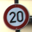

In [ ]:
data[0]

In [ ]:
labels

array([ 0,  0,  0, ..., 42, 42, 42])

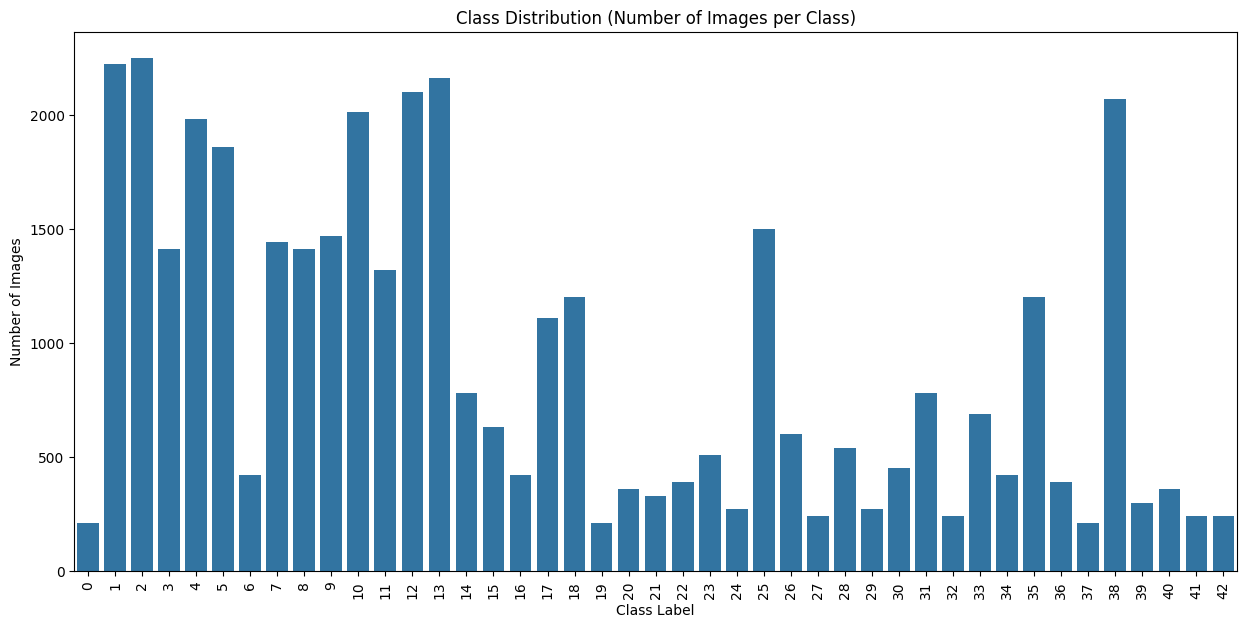

In [ ]:
plt.figure(figsize=(15, 7))
sns.countplot(x=labels)
plt.title('Class Distribution (Number of Images per Class)')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)
plt.show()

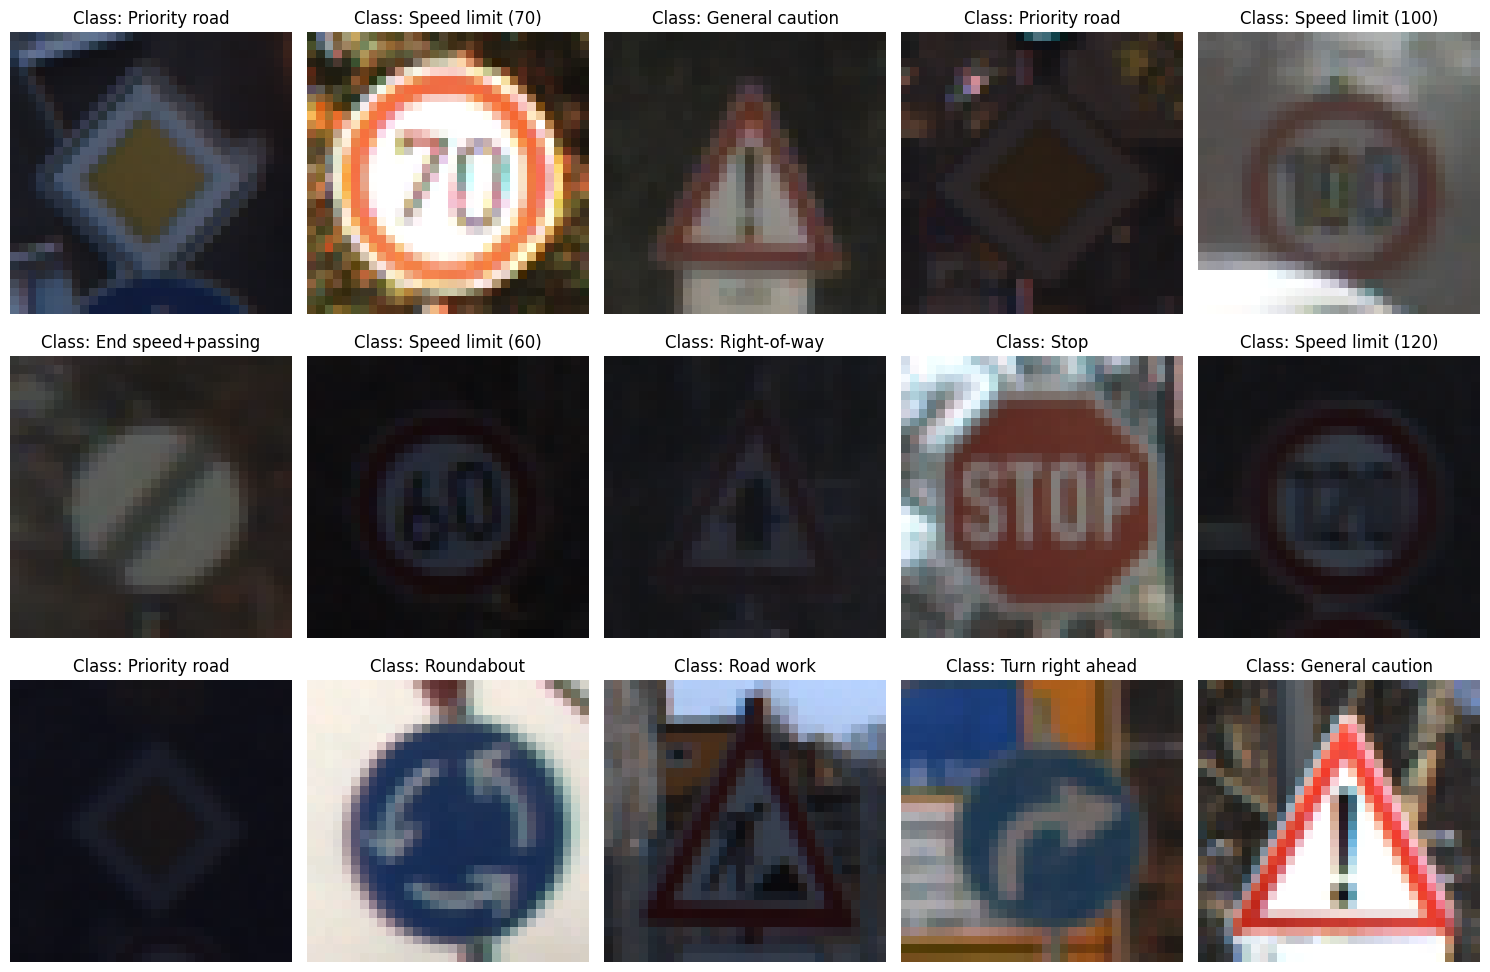

In [ ]:
import random

num_samples = 15

plt.figure(figsize=(15, 10))

for i in range(num_samples):
    index = random.randint(0, len(data) - 1)
    plt.subplot(3, 5, i + 1)
    plt.imshow(data[index])
    plt.title(f"Class: {CLASS_NAMES[labels[index]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
X_train_raw = data
y_train = labels
X_test_raw = test_data
y_test = test_labels

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Chuẩn hóa ảnh về dải [0, 1]
X_train_norm = X_train_raw / 255.0
X_test_norm = X_test_raw / 255.0

# Chuyển đổi nhãn sang dạng One-Hot Encoding
y_train_hot = to_categorical(y_train, num_classes=len(CLASS_NAMES))
y_test_hot = to_categorical(y_test, num_classes=len(CLASS_NAMES))

# In ra shape của các biến mới để kiểm tra
print(f"Shape của X_train_norm: {X_train_norm.shape}")
print(f"Shape của X_test_norm: {X_test_norm.shape}")
print(f"Shape của y_train_hot: {y_train_hot.shape}")
print(f"Shape của y_test_hot: {y_test_hot.shape}")

Shape của X_train_norm: (39209, 32, 32, 3)
Shape của X_test_norm: (12630, 32, 32, 3)
Shape của y_train_hot: (39209, 43)
Shape của y_test_hot: (12630, 43)


In [ ]:
y_train_hot[0]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Khởi tạo ImageDataGenerator với các tham số tăng cường dữ liệu
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False # Không sử dụng lật ngang
)

# Tạo train_generator
train_generator = datagen.flow(X_train_norm, y_train_hot, batch_size=64)

print("ImageDataGenerator và train_generator đã được tạo thành công.")

ImageDataGenerator và train_generator đã được tạo thành công.


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Tách tập X_train_norm và y_train_hot thành tập Train thực sự (80%) và tập Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_train_norm, y_train_hot, test_size=0.2, random_state=42)

print(f"Shape của X_train: {X_train.shape}")
print(f"Shape của X_val: {X_val.shape}")
print(f"Shape của y_train: {y_train.shape}")
print(f"Shape của y_val: {y_val.shape}")

# 2. Thiết kế kiến trúc Custom CNN nhỏ
model = Sequential([
    # Khối Conv 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Khối Conv 2
    Conv2D(32, (3, 3), activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Lớp Flatten
    Flatten(),

    # Lớp Dense thứ nhất (feature_dense)
    Dense(256, activation='relu', name='feature_dense'),
    Dropout(0.5),

    # Lớp Dense cuối cùng
    Dense(len(CLASS_NAMES), activation='softmax')
])

# In tóm tắt mô hình
model.summary()

# 3. Compile mô hình
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Thiết lập Callbacks
early_stopping = EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, monitor='val_loss', factor=0.5, min_lr=0.00001)

callbacks = [early_stopping, reduce_lr]

# 5. Tiến hành .fit() mô hình
history = model.fit(
    train_generator, # Sử dụng train_generator cho tập huấn luyện
    epochs=30,
    validation_data=(X_val, y_val), # Sử dụng X_val, y_val cho tập validation
    callbacks=callbacks
)

Shape của X_train: (31367, 32, 32, 3)
Shape của X_val: (7842, 32, 32, 3)
Shape của y_train: (31367, 43)
Shape của y_val: (7842, 43)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_dense (Dense)           │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,259 (1.82 MB)

 Trainable params: 477,259 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 214s 344ms/step - accuracy: 0.4049 - loss: 2.0595 - val_accuracy: 0.8791 - val_loss: 0.3815 - learning_rate: 0.0010
Epoch 2/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 212s 346ms/step - accuracy: 0.8028 - loss: 0.6247 - val_accuracy: 0.9857 - val_loss: 0.0649 - learning_rate: 0.0010
Epoch 3/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 214s 349ms/step - accuracy: 0.8942 - loss: 0.3434 - val_accuracy: 0.9874 - val_loss: 0.0426 - learning_rate: 0.0010
Epoch 4/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 222s 361ms/step - accuracy: 0.9249 - loss: 0.2378 - val_accuracy: 0.9893 - val_loss: 0.0292 - learning_rate: 0.0010
Epoch 5/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 212s 346ms/step - accuracy: 0.9395 - loss: 0.1905 - val_accuracy: 0.9929 - val_loss: 0.0241 - learning_rate: 0.0010
Epoch 6/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 214s 349ms/step - accuracy: 0.9524 - loss: 0.1531 - val_accuracy: 0.9972 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 7/30
613/613 ━━━━━━━━━━━━━━━━━━━━ 213s 347ms/step - accura

In [ ]:
from tensorflow.keras.models import Model
import numpy as np

# 1. Tạo mô hình feature_extractor
# Tìm lớp 'feature_dense' trong mô hình đã huấn luyện
feature_dense_output = model.get_layer('feature_dense').output

# Tạo mô hình mới với inputs là đầu vào của mô hình cũ, outputs là đầu ra của lớp 'feature_dense'
feature_extractor = Model(inputs=model.inputs, outputs=feature_dense_output)

print("Mô hình feature_extractor đã được tạo.")
feature_extractor.summary()

# 2. Trích xuất đặc trưng
X_train_features = feature_extractor.predict(X_train_norm)
X_test_features = feature_extractor.predict(X_test_norm)

print("Đặc trưng đã được trích xuất cho X_train_norm và X_test_norm.")

# 3. Chuyển đổi nhãn one-hot về dạng số nguyên 1D
y_train_labels = np.argmax(y_train_hot, axis=1)
y_test_labels = np.argmax(y_test_hot, axis=1)

print("Nhãn one-hot đã được chuyển đổi về dạng số nguyên.")

# 4. In ra shape của các biến features và labels mới
print(f"Shape của X_train_features: {X_train_features.shape}")
print(f"Shape của y_train_labels: {y_train_labels.shape}")
print(f"Shape của X_test_features: {X_test_features.shape}")
print(f"Shape của y_test_labels: {y_test_labels.shape}")

Mô hình feature_extractor đã được tạo.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_dense (Dense)           │ (None, 256)            │       409,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 466,208 (1.78 MB)

 Trainable params: 466,208 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 52s 43ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step
Đặc trưng đã được trích xuất cho X_train_norm và X_test_norm.
Nhãn one-hot đã được chuyển đổi về dạng số nguyên.
Shape của X_train_features: (39209, 256)
Shape của y_train_labels: (39209,)
Shape của X_test_features: (12630, 256)
Shape của y_test_labels: (12630,)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import time
import numpy as np




In [ ]:
# 1. Chuẩn hóa dữ liệu (Standardization)
scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_features)
X_test_svm = scaler.transform(X_test_features)

print("Dữ liệu đặc trưng đã được chuẩn hóa.")

Dữ liệu đặc trưng đã được chuẩn hóa.


In [ ]:

# 2. Lấy mẫu phụ để Tuning (Subsampling)
X_tune, _, y_tune, _ = train_test_split(X_train_svm, y_train_labels,
                                          test_size=0.85, # Lấy 15% cho tập tune
                                          stratify=y_train_labels,
                                          random_state=42)

print(f"Shape của tập Tune (X_tune): {X_tune.shape}")
print(f"Shape của tập Tune (y_tune): {y_tune.shape}")

# 3. Tìm kiếm lưới (GridSearchCV)
base_svc = SVC(class_weight='balanced', random_state=42)

param_grid = [
    {'kernel': ['linear'],
     'C': [0.1, 1, 10]
     },
    {'kernel': ['rbf'],
     'C': [0.1, 1, 10],
     'gamma': ['scale', 0.01, 0.001]},
    {'kernel': ['poly'],
     'C': [0.1, 1],
     'degree': [2, 3],
     'gamma': ['scale']},
    {'kernel': ['sigmoid'],
     'C': [0.1, 1],
     'gamma': ['scale']}
]

grid_search = GridSearchCV(estimator=base_svc,
                           param_grid=param_grid,
                           cv=3,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=3)

print("Bắt đầu tìm kiếm lưới...")
grid_search.fit(X_tune, y_tune)

print("Tìm kiếm lưới hoàn tất.")
print(f"Bộ tham số tốt nhất: {grid_search.best_params_}")



Shape của tập Tune (X_tune): (5881, 256)
Shape của tập Tune (y_tune): (5881,)
Bắt đầu tìm kiếm lưới...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Tìm kiếm lưới hoàn tất.
Bộ tham số tốt nhất: {'C': 1, 'kernel': 'linear'}


In [ ]:
# Tạo pandas DataFrame từ grid.cv_results_
results_df = pd.DataFrame(grid_search.cv_results_)

# Chỉ lấy các cột được yêu cầu
columns_to_display = [
    'param_kernel', 'param_C', 'param_gamma', 'param_degree',
    'mean_test_score', 'std_test_score', 'mean_fit_time'
]

# Kiểm tra và thêm các cột nếu chúng tồn tại (gamma, degree chỉ có với một số kernel)
actual_columns = [col for col in columns_to_display if col in results_df.columns]
filtered_results_df = results_df[actual_columns]

# Sắp xếp bảng theo mean_test_score giảm dần
filtered_results_df = filtered_results_df.sort_values(by='mean_test_score', ascending=False)

print("Top 10 cấu hình tốt nhất:")
display(filtered_results_df.head(10))

Top 10 cấu hình tốt nhất:


,param_kernel,param_C,param_gamma,param_degree,mean_test_score,std_test_score,mean_fit_time
1,linear,1.0,NaN,NaN,0.998130,0.000636,0.354897
2,linear,10.0,NaN,NaN,0.998130,0.000636,0.357670
11,rbf,10.0,0.001,NaN,0.997960,0.000416,0.477952
0,linear,0.1,NaN,NaN,0.997790,0.000636,0.373124
17,sigmoid,1.0,scale,NaN,0.997450,0.001501,0.729896
6,rbf,1.0,scale,NaN,0.997109,0.000481,1.318031
9,rbf,10.0,scale,NaN,0.996939,0.000417,0.931648
7,rbf,1.0,0.01,NaN,0.994729,0.002055,1.817366
8,rbf,1.0,0.001,NaN,0.994389,0.002202,1.176576
10,rbf,10.0,0.01,NaN,0.994389,0.001103,2.325135


In [ ]:
# 4. Huấn luyện mô hình Tối thượng (Final Model)
final_svm_cnn = grid_search.best_estimator_

print("Bắt đầu huấn luyện mô hình cuối cùng trên toàn bộ tập huấn luyện...")
start_time = time.time()
final_svm_cnn.fit(X_train_svm, y_train_labels)
end_time = time.time()

training_time = end_time - start_time
print(f"Thời gian huấn luyện mô hình cuối cùng: {training_time:.2f} giây")



Bắt đầu huấn luyện mô hình cuối cùng trên toàn bộ tập huấn luyện...
Thời gian huấn luyện mô hình cuối cùng: 3.02 giây


In [ ]:
# 5. Đánh giá trên tập Test
print("Đánh giá mô hình trên tập kiểm tra...")
y_pred = final_svm_cnn.predict(X_test_svm)

accuracy = accuracy_score(y_test_labels, y_pred)
print(f"Accuracy trên tập Test: {accuracy:.4f}")

print("\nClassification Report trên tập Test:")
print(classification_report(y_test_labels, y_pred, target_names=[CLASS_NAMES[i] for i in range(len(CLASS_NAMES))]))

Đánh giá mô hình trên tập kiểm tra...
Accuracy trên tập Test: 0.9759

Classification Report trên tập Test:
                      precision    recall  f1-score   support

    Speed limit (20)       0.95      1.00      0.98        60
    Speed limit (30)       0.97      1.00      0.99       720
    Speed limit (50)       1.00      0.99      1.00       750
    Speed limit (60)       0.96      0.97      0.96       450
    Speed limit (70)       1.00      0.98      0.99       660
    Speed limit (80)       0.94      0.99      0.96       630
 End speed limit(80)       1.00      0.97      0.99       150
   Speed limit (100)       0.99      1.00      1.00       450
   Speed limit (120)       1.00      0.99      0.99       450
          No passing       0.99      1.00      0.99       480
    No passing >3.5t       0.98      1.00      0.99       660
        Right-of-way       0.95      0.99      0.97       420
       Priority road       0.98      0.98      0.98       690
               Yield    


--- Bước 2: Vẽ Ma trận nhầm lẫn (Confusion Matrix) trực quan ---


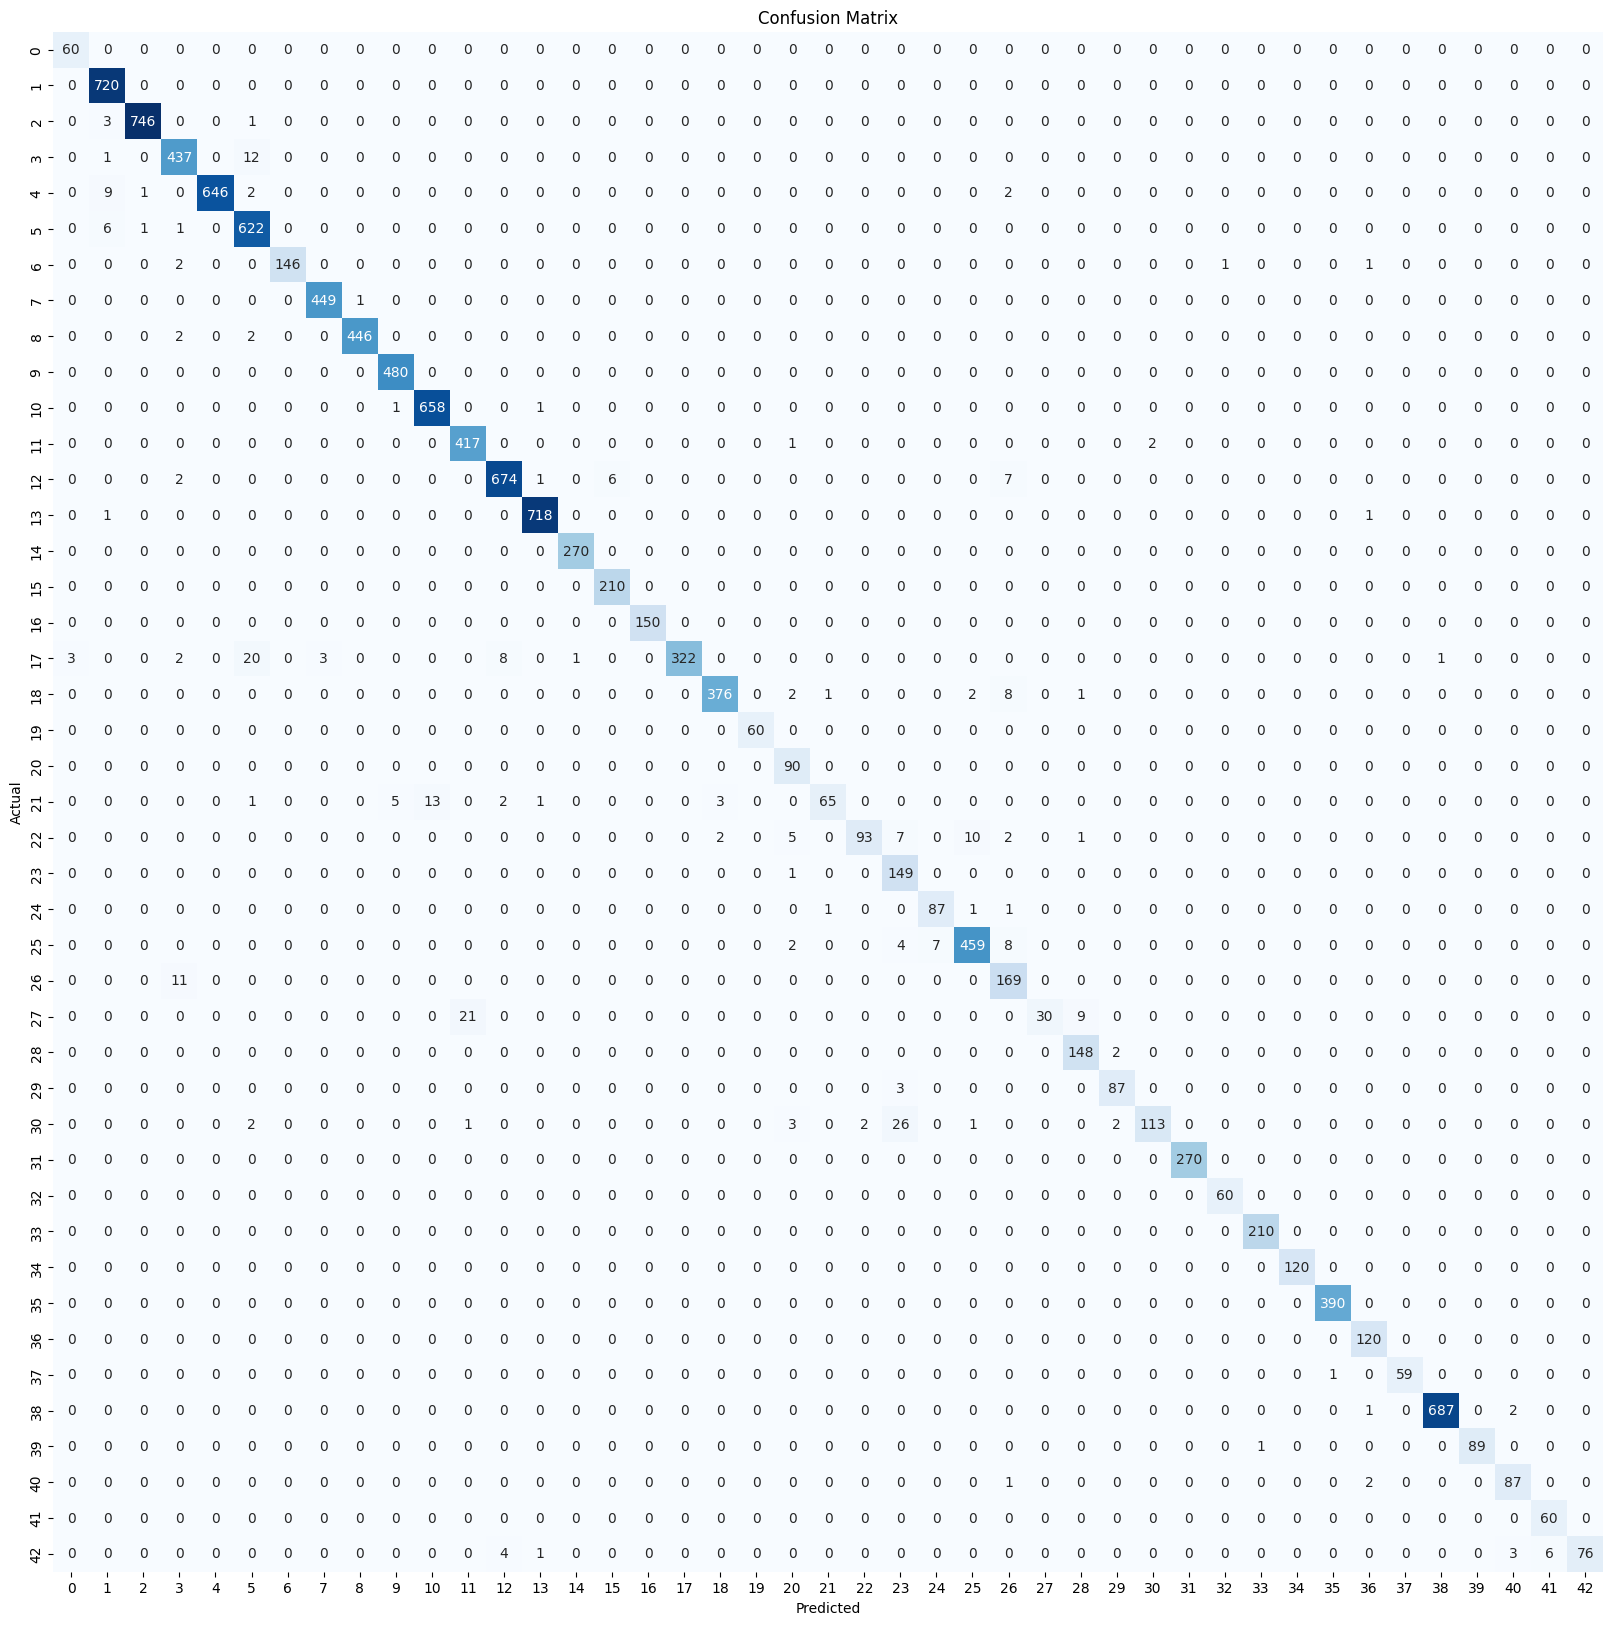

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Vẽ Ma trận nhầm lẫn (Confusion Matrix) trực quan ---
print("\n--- Bước 2: Vẽ Ma trận nhầm lẫn (Confusion Matrix) trực quan ---")
cm = confusion_matrix(y_test_labels, y_pred)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


--- Bước 3: Phân tích Lỗi (Error Analysis) - Trực quan hóa hình ảnh bị sai ---


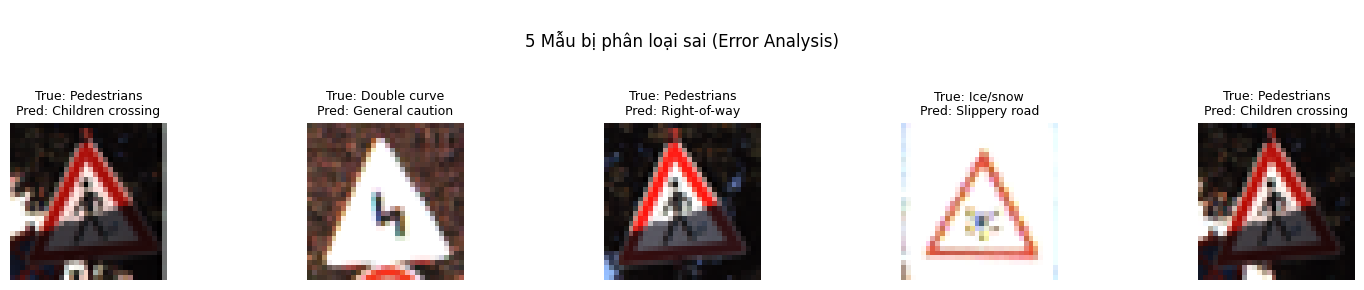

In [ ]:
import random

# --- Phân tích Lỗi (Error Analysis) - Trực quan hóa hình ảnh bị sai ---
print("\n--- Bước 3: Phân tích Lỗi (Error Analysis) - Trực quan hóa hình ảnh bị sai ---")

# Tìm các chỉ số của các mẫu bị phân loại sai
misclassified_indices = np.where(y_pred != y_test_labels)[0]

if len(misclassified_indices) == 0:
    print("Không có mẫu nào bị phân loại sai.")
else:
    # Lấy ngẫu nhiên 5 mẫu bị phân loại sai
    num_samples_to_show = min(5, len(misclassified_indices))
    random_misclassified_samples = random.sample(list(misclassified_indices), num_samples_to_show)

    plt.figure(figsize=(15, 3))
    for i, index in enumerate(random_misclassified_samples):
        plt.subplot(1, num_samples_to_show, i + 1)
        plt.imshow(X_test_raw[index]) # Hiển thị ảnh thô gốc
        true_label = CLASS_NAMES[y_test_labels[index]]
        pred_label = CLASS_NAMES[y_pred[index]]
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
        plt.axis('off')

    plt.suptitle(f"\n{num_samples_to_show} Mẫu bị phân loại sai (Error Analysis)", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

In [ ]:
print("\n--- Bước 1: Tính toán và làm rỗng đường chéo chính ---")
# cm đã được tính ở bước trước
error_cm = cm.copy()
np.fill_diagonal(error_cm, 0) # Gán giá trị trên đường chéo chính bằng 0
print("Đã tạo ma trận lỗi (error_cm) và làm rỗng đường chéo chính.")


print("\n--- Bước 2: Trích xuất Top 10 cặp nhầm lẫn nhiều nhất ---")

# Tìm tọa độ của các giá trị lớn nhất trong error_cm
# Sử dụng np.unravel_index để chuyển chỉ số phẳng thành chỉ số 2D (hàng, cột)
# Lấy 10 chỉ số lớn nhất
flat_indices = np.argsort(error_cm.ravel())[::-1][:10]
row_indices, col_indices = np.unravel_index(flat_indices, error_cm.shape)

# Tạo DataFrame để lưu kết quả
top_misclassifications = pd.DataFrame(columns=[
    'Nhãn thực tế (True Label)',
    'Nhãn dự đoán (Predicted)',
    'Tên biển báo thực tế',
    'Tên biển báo dự đoán',
    'Số lần nhầm lẫn'
])

for i in range(10):
    true_label_idx = row_indices[i]
    pred_label_idx = col_indices[i]
    count = error_cm[true_label_idx, pred_label_idx]

    # Lấy tên biển báo từ CLASS_NAMES
    true_sign_name = CLASS_NAMES[true_label_idx]
    pred_sign_name = CLASS_NAMES[pred_label_idx]

    top_misclassifications.loc[i] = [
        true_label_idx,
        pred_label_idx,
        true_sign_name,
        pred_sign_name,
        count
    ]

print("Top 10 cặp nhầm lẫn nhiều nhất:")
display(top_misclassifications)


--- Bước 1: Tính toán và làm rỗng đường chéo chính ---
Đã tạo ma trận lỗi (error_cm) và làm rỗng đường chéo chính.

--- Bước 2: Trích xuất Top 10 cặp nhầm lẫn nhiều nhất ---
Top 10 cặp nhầm lẫn nhiều nhất:


,Nhãn thực tế (True Label),Nhãn dự đoán (Predicted),Tên biển báo thực tế,Tên biển báo dự đoán,Số lần nhầm lẫn
0,30,23,Ice/snow,Slippery road,26
1,27,11,Pedestrians,Right-of-way,21
2,17,5,No entry,Speed limit (80),20
3,21,10,Double curve,No passing >3.5t,13
4,3,5,Speed limit (60),Speed limit (80),12
5,26,3,Traffic signals,Speed limit (60),11
6,22,25,Bumpy road,Road work,10
7,4,1,Speed limit (70),Speed limit (30),9
8,27,28,Pedestrians,Children crossing,9
9,17,12,No entry,Priority road,8


In [ ]:
import joblib
from google.colab import files


# ==========================================
# BƯỚC 1: LƯU TRỮ MÔ HÌNH
# ==========================================
print("Đang lưu trữ hệ thống mô hình Lai ghép...")
# Lưu bộ trích xuất đặc trưng CNN (Keras)
feature_extractor.save('/content/drive/MyDrive/gtsrb_dataset/cnn_feature_extractor.h5')
# Lưu bộ chuẩn hóa StandardScaler
joblib.dump(scaler, '/content/drive/MyDrive/gtsrb_dataset/svm_scaler.pkl')
# Lưu mô hình SVM Tối thượng (Scikit-learn)
joblib.dump(final_svm_cnn, '/content/drive/MyDrive/gtsrb_dataset/final_hybrid_svm.pkl')
print("Đã lưu thành công! Bạn có thể tải các file này về máy tính cá nhân.")

Đang lưu trữ hệ thống mô hình Lai ghép...
Đã lưu thành công! Bạn có thể tải các file này về máy tính cá nhân.



Hãy tải lên một bức ảnh biển báo bạn tìm thấy trên mạng để kiểm tra:


Saving Screenshot 2026-03-28 113727.jpg to Screenshot 2026-03-28 113727.jpg


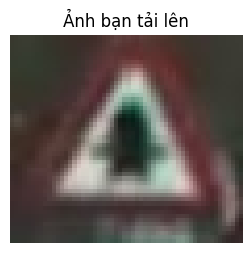

🎯 KẾT QUẢ DỰ ĐOÁN:
Biển báo: Right-of-way
Khoảng cách Margin (Confidence): 42.33


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ==========================================
# BƯỚC 2: XÂY DỰNG HÀM DỰ ĐOÁN ẢNH THỰC TẾ (INFERENCE PIPELINE)
# ==========================================
def predict_real_image_hybrid(image_path_or_bytes):
    try:
        if isinstance(image_path_or_bytes, bytes):
            img = Image.open(io.BytesIO(image_path_or_bytes)).convert('RGB')
        else:
            img = Image.open(image_path_or_bytes).convert('RGB')
    except Exception as e:
        print("Lỗi đọc ảnh:", e)
        return

    # Hiển thị ảnh upload
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title("Ảnh bạn tải lên")
    plt.axis('off')
    plt.show()

    # 1. Tiền xử lý (Giống hệt lúc train CNN)
    img_resized = img.resize((32, 32))
    img_array = np.array(img_resized) / 255.0  # Normalize [0, 1]
    img_batch = np.expand_dims(img_array, axis=0) # Shape (1, 32, 32, 3)

    # 2. Trích xuất đặc trưng (CNN Feature Extraction)
    # Lấy ra vector 256 chiều
    deep_features = feature_extractor.predict(img_batch, verbose=0)

    # 3. Chuẩn hóa đặc trưng (SVM Scaler)
    scaled_features = scaler.transform(deep_features)

    # 4. Phân loại bằng SVM (Linear Kernel)
    pred_idx = final_svm_cnn.predict(scaled_features)[0]

    # Tính độ tin cậy (Khoảng cách tới siêu mặt phẳng)
    decision_scores = final_svm_cnn.decision_function(scaled_features)[0]
    confidence = decision_scores[pred_idx]

    print("="*40)
    print(f"🎯 KẾT QUẢ DỰ ĐOÁN:")
    print(f"Biển báo: {CLASS_NAMES[pred_idx]}")
    print(f"Khoảng cách Margin (Confidence): {confidence:.2f}")
    print("="*40)

# ==========================================
# BƯỚC 3: UPLOAD ẢNH ĐỂ TEST LIVE DEMO
# ==========================================
import io
print("\nHãy tải lên một bức ảnh biển báo bạn tìm thấy trên mạng để kiểm tra:")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    img_bytes = uploaded[filename]
    predict_real_image_hybrid(img_bytes)